# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Antung Fatimah
- **Email:** antungfatimah1@gmail.com


## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren jumlah pesanan (order) secara bulanan (Month-over-Month) sepanjang periode Januari 2017–Agustus 2018, dan pada bulan apa terjadi penurunan jumlah order terbesar?**
   - *Specific*: fokus pada tren jumlah order bulanan.
   - *Measurable*: dihitung dari jumlah order per bulan dan persentase perubahan MoM.
   - *Action-Oriented*: jika ditemukan bulan dengan penurunan tajam, tim bisa menelusuri penyebabnya (musiman, operasional, dsb.) dan menyiapkan mitigasi di periode serupa berikutnya.
   - *Relevant*: memahami tren order adalah dasar perencanaan stok & kampanye.
   - *Time-bound*: dibatasi periode Januari 2017–Agustus 2018 (rentang data yang tersedia).

2. **Kategori produk apa yang menghasilkan revenue tertinggi selama periode Januari 2017–Agustus 2018, dan bagaimana rata-rata skor review pelanggan untuk kategori tersebut?**
   - *Specific*: fokus pada revenue per kategori produk beserta rata-rata review score-nya.
   - *Measurable*: dihitung dari total `price` per kategori dan rata-rata `review_score`.
   - *Action-Oriented*: kategori dengan revenue tinggi tapi review rendah menandakan perlu perbaikan kualitas/pengalaman; kategori revenue tinggi & review tinggi layak diprioritaskan dalam promosi.
   - *Relevant*: langsung berkaitan dengan strategi produk dan kepuasan pelanggan.
   - *Time-bound*: dibatasi periode Januari 2017–Agustus 2018.



In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Data Wrangling

In [12]:
# Load seluruh dataset ke dalam DataFrame
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")
sellers_df = pd.read_csv("sellers_dataset.csv")

print("customers_df :", customers_df.shape)
print("orders_df :", orders_df.shape)
print("order_items_df :", order_items_df.shape)
print("order_payments_df :", order_payments_df.shape)
print("order_reviews_df :", order_reviews_df.shape)
print("products_df :", products_df.shape)
print("category_translation_df :", category_translation_df.shape)
print("sellers_df :", sellers_df.shape)

customers_df : (99441, 5)
orders_df : (99441, 8)
order_items_df : (112650, 7)
order_payments_df : (103886, 5)
order_reviews_df : (99224, 7)
products_df : (32951, 9)
category_translation_df : (71, 2)
sellers_df : (3095, 4)


Gathering Data

In [9]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Assessing Data

Pada tahap ini kita mengecek beberapa potensi masalah:
1. **Missing value** — kolom mana saja yang punya nilai kosong.
2. **Duplicate data** — apakah ada baris yang terduplikasi.
3. **Tipe data tidak sesuai** — misalnya kolom tanggal yang masih bertipe `object`/string.
4. **Invalid/outlier value** — misalnya harga atau ongkir bernilai negatif/ekstrem.

In [14]:
# 1. Cek missing value di tiap dataset utama
for name, df in [
    ("orders_df", orders_df),
    ("order_items_df", order_items_df),
    ("order_payments_df", order_payments_df),
    ("order_reviews_df", order_reviews_df),
    ("products_df", products_df),
    ("customers_df", customers_df),
]:
    print(f"--- {name} ---")
    print(df.isna().sum()[df.isna().sum() > 0])
    print()

--- orders_df ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- order_items_df ---
Series([], dtype: int64)

--- order_payments_df ---
Series([], dtype: int64)

--- order_reviews_df ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- products_df ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- customers_df ---
Series([], dtype: int64)



In [15]:
# 2. Cek duplicate data
for name, df in [
    ("orders_df", orders_df),
    ("order_items_df", order_items_df),
    ("order_payments_df", order_payments_df),
    ("order_reviews_df", order_reviews_df),
    ("products_df", products_df),
    ("customers_df", customers_df),
]:
    print(f"{name}: {df.duplicated().sum()} baris duplikat")

orders_df: 0 baris duplikat
order_items_df: 0 baris duplikat
order_payments_df: 0 baris duplikat
order_reviews_df: 0 baris duplikat
products_df: 0 baris duplikat
customers_df: 0 baris duplikat


In [16]:
# 3. Cek tipe data kolom tanggal pada orders_df (masih object, seharusnya datetime)
orders_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


In [17]:
# 4. Cek nilai invalid/outlier sederhana pada price & freight_value
print(order_items_df[["price", "freight_value"]].describe())
print("\nJumlah price <= 0:", (order_items_df["price"] <= 0).sum())

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

Jumlah price <= 0: 0


**Ringkasan temuan & rencana perbaikan:**

- `orders_df` punya missing value di `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` — wajar karena sebagian order belum/tidak selesai diproses (status `canceled`/`unavailable`). Solusi: biarkan sebagai `NaT` (tidak diisi paksa) dan catat ketika dipakai untuk analisis waktu pengiriman, filter hanya order dengan status `delivered`.
- `products_df` punya missing value di `product_category_name` dan atribut dimensi produk. Solusi: baris dengan kategori kosong diberi label `"unknown"` atau di-drop tergantung kebutuhan analisis.
- Kolom tanggal di `orders_df` bertipe `object`. Solusi: convert ke `datetime` dengan `pd.to_datetime`.
- Tidak ditemukan data duplikat signifikan pada pengecekan awal.

### Cleaning Data

In [18]:
# Convert kolom tanggal ke datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

orders_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [19]:
# Tangani missing value pada products_df: isi kategori kosong dengan 'unknown'
products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

# Gabungkan nama kategori Bahasa Inggris
products_df = products_df.merge(category_translation_df, how="left", on="product_category_name")
products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")

products_df[["product_id", "product_category_name", "product_category_name_english"]].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [20]:
# Drop duplikat (jaga-jaga) & pastikan tidak ada order_id kosong pada tabel transaksional
orders_df = orders_df.drop_duplicates()
order_items_df = order_items_df.drop_duplicates()
order_payments_df = order_payments_df.drop_duplicates()

orders_df = orders_df.dropna(subset=["order_id", "customer_id"])
order_items_df = order_items_df.dropna(subset=["order_id", "product_id"])

print("Setelah cleaning ->")
print("orders_df :", orders_df.shape)
print("order_items_df :", order_items_df.shape)
print("order_payments_df :", order_payments_df.shape)

Setelah cleaning ->
orders_df : (99441, 8)
order_items_df : (112650, 7)
order_payments_df : (103886, 5)


## Exploratory Data Analysis (EDA)

Sebelum menjawab pertanyaan bisnis, kita gabungkan (`merge`) beberapa tabel menjadi satu `main_df`
yang memuat informasi order, item, pembayaran, kategori produk, review, dan lokasi pelanggan.

In [21]:
# Gabungkan order_items dengan orders (hanya order berstatus delivered untuk analisis transaksi)
main_df = order_items_df.merge(orders_df, on="order_id", how="left")
main_df = main_df.merge(products_df[["product_id", "product_category_name_english"]], on="product_id", how="left")
main_df = main_df.merge(customers_df, on="customer_id", how="left")

# Rata-rata review_score per order digabung ke main_df
review_score_df = order_reviews_df.groupby("order_id")["review_score"].mean().reset_index()
main_df = main_df.merge(review_score_df, on="order_id", how="left")

print(main_df.shape)
main_df.head()

(112650, 20)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,cool_stuff,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,perfumery,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,garden_tools,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,5.0


### Pertanyaan Bisnis 1: Tren jumlah order bulanan

In [23]:
delivered_df = main_df[main_df["order_status"] == "delivered"].copy()
delivered_df["order_month"] = delivered_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Fokuskan pada periode Jan 2017 - Agu 2018 sesuai cakupan pertanyaan bisnis
# (beberapa order di luar rentang ini jumlahnya sangat sedikit/noise, mis. hanya 1 order)
delivered_df = delivered_df[
    (delivered_df["order_month"] >= "2017-01") & (delivered_df["order_month"] <= "2018-08")
]

# Hitung jumlah order unik per bulan
monthly_orders = (
    delivered_df.drop_duplicates("order_id")
    .groupby("order_month")["order_id"]
    .nunique()
    .reset_index(name="order_count")
    .sort_values("order_month")
)

# Hitung persentase perubahan Month-over-Month
monthly_orders["mom_growth_%"] = monthly_orders["order_count"].pct_change() * 100
monthly_orders

,order_month,order_count,mom_growth_%
0,2017-01,750,NaN
1,2017-02,1653,120.400000
2,2017-03,2546,54.022989
3,2017-04,2303,-9.544383
4,2017-05,3546,53.973079
5,2017-06,3135,-11.590525
6,2017-07,3872,23.508772
7,2017-08,4193,8.290289
8,2017-09,4150,-1.025519
9,2017-10,4478,7.903614


In [24]:
# Bulan dengan penurunan (MoM) terbesar
biggest_drop = monthly_orders.loc[monthly_orders["mom_growth_%"].idxmin()]
print("Bulan dengan penurunan order terbesar:")
print(biggest_drop)

Bulan dengan penurunan order terbesar:
order_month       2017-12
order_count          5513
mom_growth_%   -24.365482
Name: 11, dtype: object


### Pertanyaan Bisnis 2: Revenue & review score per kategori produk

In [25]:
category_summary = (
    main_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        total_items_sold=("order_item_id", "count"),
        avg_review_score=("review_score", "mean"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top10_category = category_summary.head(10)
top10_category

,product_category_name_english,total_revenue,total_items_sold,avg_review_score
43,health_beauty,1258681.34,9670,4.141827
71,watches_gifts,1205005.68,5991,4.018855
7,bed_bath_table,1036988.68,11115,3.898334
65,sports_leisure,988048.97,8641,4.107039
15,computers_accessories,911954.32,7827,3.932601
39,furniture_decor,729762.49,8334,3.907333
20,cool_stuff,635290.85,3796,4.146598
49,housewares,632248.66,6964,4.054785
5,auto,592720.11,4235,4.064885
42,garden_tools,485256.46,4347,4.045539


### (Opsional/Bonus) RFM Analysis

Sebagai analisis lanjutan (tanpa machine learning), kita hitung Recency, Frequency, Monetary per pelanggan (customer_unique_id) untuk melihat segmentasi perilaku pembelian.

In [26]:
rfm_base = delivered_df.dropna(subset=["order_purchase_timestamp"]).drop_duplicates("order_id")

payments_per_order = order_payments_df.groupby("order_id")["payment_value"].sum().reset_index()
rfm_base = rfm_base.merge(payments_per_order, on="order_id", how="left")

snapshot_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()

# Manual grouping / binning sederhana untuk segmentasi (bukan algoritma ML)
rfm_df["recency_score"] = pd.qcut(rfm_df["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["monetary_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

def segment_customer(row):
    if row["recency_score"] >= 3 and row["monetary_score"] >= 3:
        return "Top Customer"
    elif row["recency_score"] >= 3:
        return "Recent, Low Spender"
    elif row["monetary_score"] >= 3:
        return "Lapsed, High Spender"
    else:
        return "At Risk"

rfm_df["segment"] = rfm_df.apply(segment_customer, axis=1)
rfm_df.head()

,customer_unique_id,recency,frequency,monetary,recency_score,monetary_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,3,Top Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,"Recent, Low Spender"
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,4,"Lapsed, High Spender"


## Visualization & Explanatory Analysis

### Visualisasi 1: Tren jumlah order bulanan (menjawab Pertanyaan Bisnis 1)

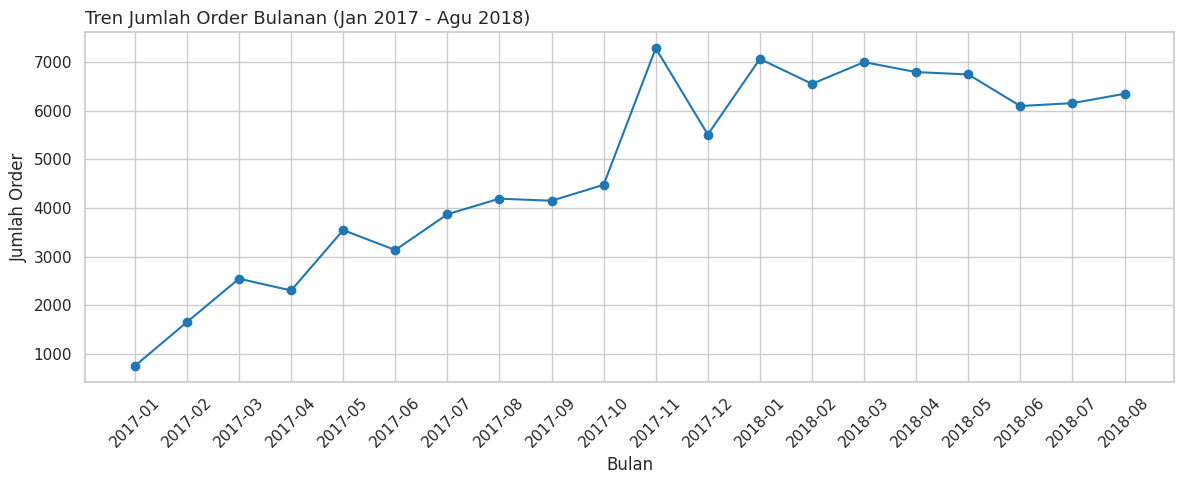

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_orders["order_month"], monthly_orders["order_count"], marker="o", color="#1f77b4")
ax.set_title("Tren Jumlah Order Bulanan (Jan 2017 - Agu 2018)", fontsize=13, loc="left")
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualisasi 2: Top 10 kategori produk berdasarkan revenue (menjawab Pertanyaan Bisnis 2)

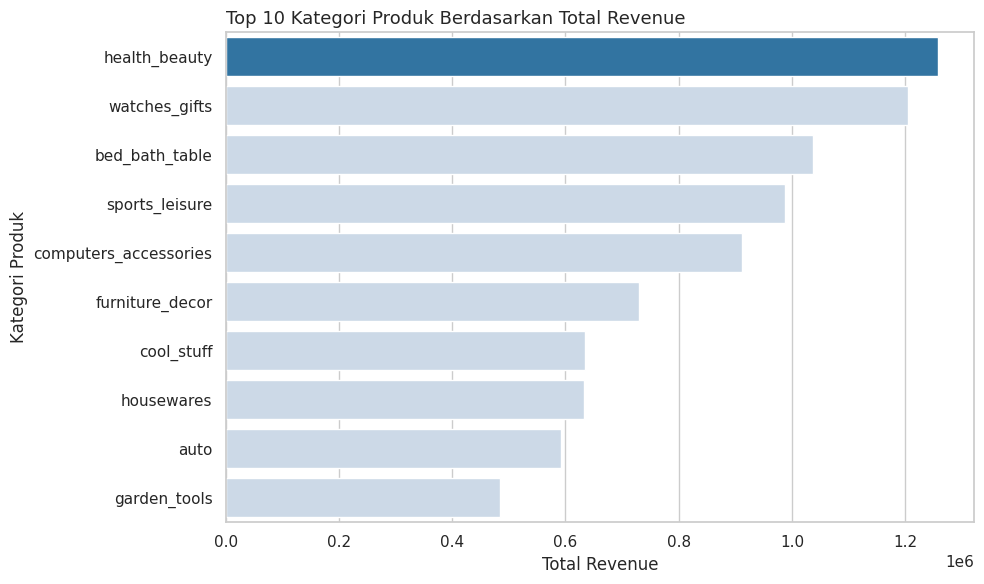

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
top10_category = top10_category.copy()
top10_category["highlight"] = ["Top 1"] + ["Lainnya"] * (len(top10_category) - 1)
sns.barplot(
    data=top10_category,
    y="product_category_name_english",
    x="total_revenue",
    hue="highlight",
    palette={"Top 1": "#1f77b4", "Lainnya": "#c7d9ec"},
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 Kategori Produk Berdasarkan Total Revenue", fontsize=13, loc="left")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

Visualisasi 3 (Bonus): Distribusi segmen pelanggan hasil RFM Analysis

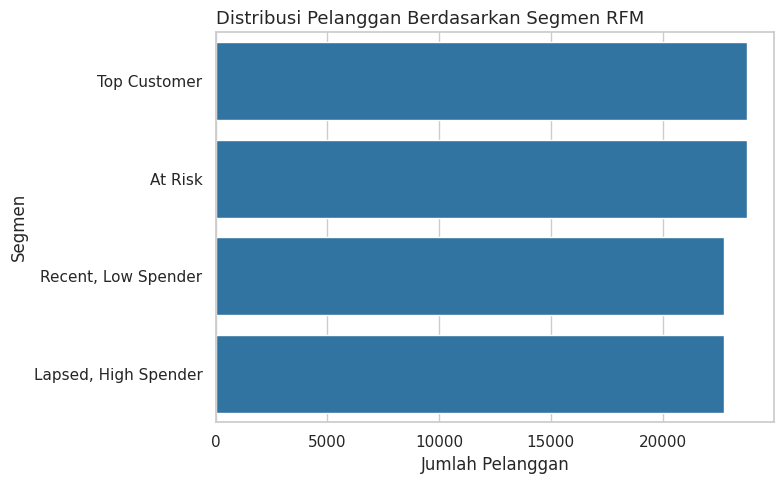

In [29]:
segment_counts = rfm_df["segment"].value_counts().reset_index()
segment_counts.columns = ["segment", "customer_count"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=segment_counts, x="customer_count", y="segment", color="#1f77b4", ax=ax)
ax.set_title("Distribusi Pelanggan Berdasarkan Segmen RFM", fontsize=13, loc="left")
ax.set_xlabel("Jumlah Pelanggan")
ax.set_ylabel("Segmen")
plt.tight_layout()
plt.show()

## Conclusion

**Conclusion Pertanyaan Bisnis 1 (Tren order bulanan):**
Jumlah order bulanan menunjukkan tren pertumbuhan yang kuat sepanjang 2017, dari 750 order di Januari 2017 melonjak ke puncaknya 7.289 order di November 2017 (didorong oleh periode Black Friday). Setelah itu order sempat turun ke 5.513 di Desember 2017, lalu kembali naik ke 7.069 di Januari 2018, dan sejak itu jumlah order relatif stabil di kisaran 6.000-7.000 order/bulan hingga Agustus 2018.

Penurunan Month-over-Month terbesar terjadi pada **Desember 2017**, turun **-24,37%** (dari 7.289 order di November menjadi 5.513 order di Desember). Ini kemungkinan terkait efek "hangover" pasca-lonjakan Black Friday November, di mana pembeli sudah memenuhi kebutuhan belanjanya lebih awal sehingga permintaan Desember melambat.

**Conclusion Pertanyaan Bisnis 2 (Revenue & review per kategori):**
Tiga kategori dengan revenue tertinggi adalah **health_beauty** (R$ 1.258.681, avg review 4,14), **watches_gifts** (R$ 1.205.006, avg review 4,02), dan **bed_bath_table** (R$ 1.036.989, avg review 3,90 — review rata-rata terendah di antara top 10 kategori). Secara umum, seluruh kategori top 10 punya rata-rata review score di atas 3,9, artinya tidak ada kategori bervolume tinggi yang bermasalah serius dari sisi kepuasan pelanggan. Namun **bed_bath_table** dan **computers_accessories** (3,93) berada di titik terendah dari top 10, sehingga tetap layak menjadi prioritas evaluasi kualitas dibanding kategori lain seperti **cool_stuff** (4,15) yang punya review tertinggi.

**(Bonus) Hasil RFM Analysis:**
Dari 93.104 pelanggan unik yang dianalisis, segmentasi terbagi cukup merata: **Top Customer** 23.795 pelanggan (25,6%), **At Risk** 23.783 pelanggan (25,5%), **Recent, Low Spender** 22.769 pelanggan (24,5%), dan **Lapsed, High Spender** 22.757 pelanggan (24,4%). Seperempat basis pelanggan tergolong "At Risk" (sudah lama tidak transaksi dan nilai belanjanya rendah), sementara jumlah "Top Customer" hampir sama besarnya — menunjukkan ada peluang besar untuk program retensi karena populasi pelanggan bernilai rendah/berisiko churn cukup signifikan.

**Rekomendasi (Action Item):**
1. Untuk mengantisipasi pola penurunan order pasca-Black Friday (seperti yang terjadi di Desember 2017), tim marketing dapat menyiapkan kampanye promosi susulan di awal Desember agar momentum belanja tidak turun drastis setelah November.
2. Kategori **bed_bath_table** dan **computers_accessories**, meski revenue-nya tinggi, punya rata-rata review paling rendah di antara top 10 kategori — tim kualitas/logistik perlu audit proses (kualitas produk, kecepatan pengiriman, kesesuaian deskripsi) di kedua kategori ini agar tidak menggerus kepuasan pelanggan pada kategori bernilai tinggi.
3. (Bonus) Segmen **"At Risk"** (23.783 pelanggan, ~25,5% dari total) sebaiknya menjadi target utama kampanye reaktivasi (voucher/diskon khusus) untuk mencegah churn, mengingat jumlahnya hampir setara dengan segmen "Top Customer".


## Menyimpan Data untuk Dashboard

In [30]:
import os
os.makedirs("dashboard", exist_ok=True)
main_df.to_csv("dashboard/main_data.csv", index=False)
print("Tersimpan di dashboard/main_data.csv, shape:", main_df.shape)

Tersimpan di dashboard/main_data.csv, shape: (112650, 20)
